Часть 2. Марковские цепи. Симуляция марковской цепи

In [2]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 39.9 MB/s eta 0:00:00


Исходная матрица P:
 [[0.30165913 0.20135747 0.20173454 0.29524887]
 [0.25316456 0.31289557 0.24841772 0.18552215]
 [0.1995094  0.29026983 0.31766149 0.19255928]
 [0.30467762 0.20817531 0.2132322  0.27391488]]

Эмпирическая матрица переходов (средняя по 10 синт. последовательностям):
 [[0.3036316  0.2006739  0.19543242 0.30026207]
 [0.24367724 0.3099157  0.25291048 0.19349659]
 [0.21213355 0.26913681 0.33346906 0.18526059]
 [0.30817875 0.22006745 0.20489039 0.26686341]]


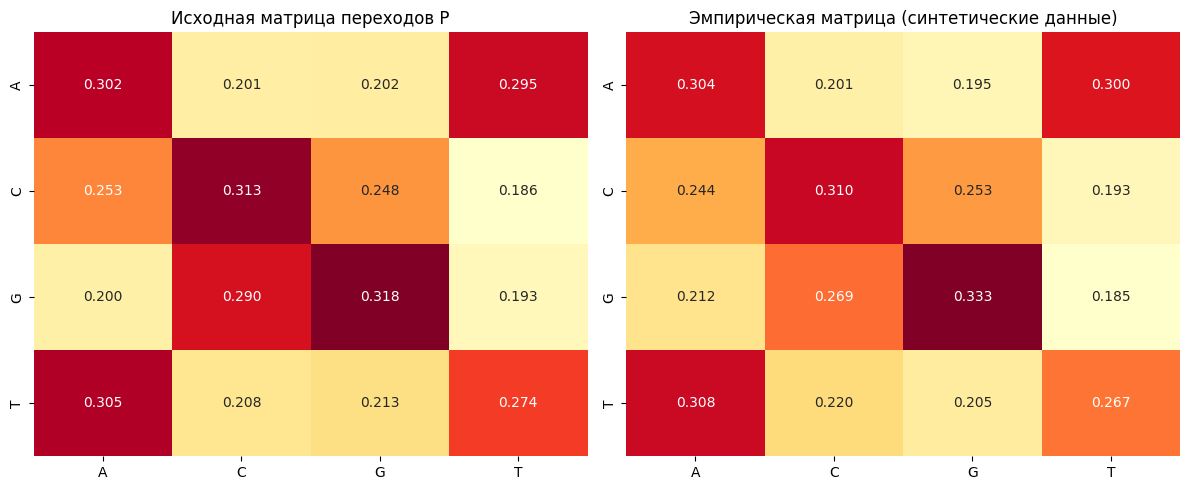

Максимальное абсолютное отклонение: 0.0211
Чем ближе к нулю, тем точнее симуляция воспроизводит цепь.


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Используем матрицу P из задания 5
P = np.array([[0.30165913, 0.20135747, 0.20173454, 0.29524887],
              [0.25316456, 0.31289557, 0.24841772, 0.18552215],
              [0.1995094 , 0.29026983, 0.31766149, 0.19255928],
              [0.30467762, 0.20817531, 0.2132322 , 0.27391488]])
nucleotides = ['A','C','G','T']
idx_map = {n:i for i,n in enumerate(nucleotides)}

# Функция генерации последовательности
def generate_sequence(P, length, start_state=None, rng=np.random.default_rng()):
    if start_state is None:
        start_state = rng.choice(nucleotides)
    seq = [start_state]
    current_idx = idx_map[start_state]
    for _ in range(length-1):
        next_idx = rng.choice(len(nucleotides), p=P[current_idx])
        seq.append(nucleotides[next_idx])
        current_idx = next_idx
    return ''.join(seq)

# Генерация 10 последовательностей длиной 1000
num_seqs = 10
length = 1000
rng = np.random.default_rng(2024)
synthetic_seqs = [generate_sequence(P, length, rng=rng) for _ in range(num_seqs)]

# Подсчёт эмпирических частот динуклеотидов
empirical_dinuc = np.zeros((4,4))
for seq in synthetic_seqs:
    for i in range(len(seq)-1):
        a, b = idx_map[seq[i]], idx_map[seq[i+1]]
        empirical_dinuc[a,b] += 1

# Нормировка по строкам, как матрицу переходов
empirical_P = empirical_dinuc / empirical_dinuc.sum(axis=1, keepdims=True)

print("Исходная матрица P:\n", P)
print("\nЭмпирическая матрица переходов (средняя по 10 синт. последовательностям):\n", empirical_P)

# Тепловые карты
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.heatmap(P, annot=True, fmt='.3f', xticklabels=nucleotides, yticklabels=nucleotides,
            cmap='YlOrRd', ax=axes[0], cbar=False)
axes[0].set_title('Исходная матрица переходов P')
sns.heatmap(empirical_P, annot=True, fmt='.3f', xticklabels=nucleotides, yticklabels=nucleotides,
            cmap='YlOrRd', ax=axes[1], cbar=False)
axes[1].set_title('Эмпирическая матрица (синтетические данные)')
plt.tight_layout()
plt.savefig("heatmap_comparison.png", dpi=150)
plt.show()


max_dev = np.max(np.abs(P - empirical_P))
print(f"Максимальное абсолютное отклонение: {max_dev:.4f}")
print("Чем ближе к нулю, тем точнее симуляция воспроизводит цепь.")